# Feature Engineering: Portfolio Concentration Features and Risk Label

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import time
import os

## Configuration

In [3]:
PROCESSED_DATA_DIR = "../../data/processed"

## Load Preprocessing Outputs

In [4]:
# Load the cleaned, forward-fill-corrected inputs produced by preprocessing.ipynb
equity_prices = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "equity_close_prices_clean.csv"), index_col=0, parse_dates=True)
df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "cleaned_holdings.csv"), dtype={"cusip": str})
mapping = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "cusip_ticker_sector_mapping_final.csv"), dtype={"cusip": str})

print(f"Equity prices: {equity_prices.shape}")
print(f"Holdings: {df.shape}")
print(f"Mapping: {mapping.shape}")

df.head()

Equity prices: (755, 3451)
Holdings: (1630738, 15)
Mapping: (41065, 4)


,cusip,cik,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09,stock,institution
0,000000008,1483232,0.0,0.0,0.0,0.0,70238.0,70238.0,70238.0,70238.0,70238.0,70238.0,70238.0,VANGUARD FTSE PACIFIC ETF,"TIEDEMANN WEALTH MANAGEMENT, LLC"
1,000000018,1177206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,980032.0,980032.0,980032.0,980032.0,Cencosud Sa,LOS ANGELES CAPITAL MANAGEMENT & EQUITY RESEAR...
2,000003128,1541743,0.0,90550.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,ABERDEEN ASSET MANAGEMENT,"Copeland Capital Management, LLC"
3,000003638,1606588,0.0,0.0,0.0,0.0,0.0,34564.0,34564.0,34564.0,34564.0,34564.0,34564.0,ISHARES TR MSCI EAFE,"One Capital Management, LLC"
4,00000C105,1226886,0.0,0.0,0.0,0.0,0.0,0.0,661967.0,661967.0,661967.0,661967.0,661967.0,CITIZENS FINANCIAL GROUP,ALPINE MANAGEMENT & RESEARCH LLC


## Source Industry Sector

`security_type` (from preprocessing) classifies instrument type, not industry. Industry sector is sourced here via `yfinance` ticker metadata. This step is checkpointed: if `sector_mapping.csv` already exists, it is loaded directly rather than re-querying the API.

In [5]:
def fetch_sector_info(ticker_list, checkpoint_path=None, checkpoint_every=100, max_retries=2):
    results = {}
    total = len(ticker_list)

    for i, ticker in enumerate(ticker_list):
        sector, industry = None, None
        for attempt in range(max_retries):
            try:
                info = yf.Ticker(ticker).info
                sector = info.get("sector") or None
                industry = info.get("industry") or None
                break
            except Exception:
                time.sleep(2)
        results[ticker] = {"sector": sector, "industry": industry}

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} / {total}")
        if checkpoint_path and (i + 1) % checkpoint_every == 0:
            pd.DataFrame.from_dict(results, orient="index").reset_index().rename(
                columns={"index": "ticker"}).to_csv(checkpoint_path, index=False)

    return results

In [6]:
sector_path = os.path.join(PROCESSED_DATA_DIR, "sector_mapping.csv")

if os.path.exists(sector_path):
    sector_df = pd.read_csv(sector_path)
else:
    sector_results = fetch_sector_info(
        equity_prices.columns.tolist(),
        checkpoint_path=os.path.join(PROCESSED_DATA_DIR, "sector_mapping_checkpoint.csv")
    )
    sector_df = pd.DataFrame.from_dict(sector_results, orient="index").reset_index().rename(columns={"index": "ticker"})
    sector_df.to_csv(sector_path, index=False)

print(f"Sector data: {sector_df.shape}")
print(f"Missing sector: {sector_df['sector'].isna().sum()} / {len(sector_df)}")

Sector data: (3451, 3)
Missing sector: 33 / 3451


## Merge Holdings, Mapping, and Sector Data

Holdings are joined to ticker and security type (via CUSIP), then to sector, and restricted to genuine equity holdings with usable price data.

In [7]:
df_merged = df.merge(mapping[["cusip", "ticker", "security_type"]], on="cusip", how="left")

equity_security_types = ["Common Stock", "Depositary Receipt", "REIT", "Preferred Stock"]
df_equity = df_merged[df_merged["security_type"].isin(equity_security_types)].copy()

df_equity = df_equity.merge(sector_df[["ticker", "sector", "industry"]], on="ticker", how="left")

usable_tickers = set(equity_prices.columns)
df_equity = df_equity[df_equity["ticker"].isin(usable_tickers)].copy()

print(f"After equity-type filter: {len(df_equity)}")
print(f"After usable-ticker filter: {len(df_equity)}")
print(f"Missing sector: {df_equity['sector'].isna().sum()} / {len(df_equity)}")

df_equity.head()

After equity-type filter: 741422
After usable-ticker filter: 741422
Missing sector: 6311 / 741422


,cusip,cik,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09,stock,institution,ticker,security_type,sector,industry
1,000304105,714142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AAC TECHNOLOGIES HLDGS INC,TEACHERS RETIREMENT SYSTEM OF THE STATE OF KEN...,AACAY,Depositary Receipt,Technology,Communication Equipment
2,000304105,820027,0.0,0.0,0.0,0.0,0.0,3084.0,2662.0,2492.0,2260.0,2260.0,2260.0,AAC TECHNOLOGIES H-UNSPON AD,AMERICAN EXPRESS FINANCIAL ADVISORS,AACAY,Depositary Receipt,Technology,Communication Equipment
3,000304105,883782,0.0,0.0,0.0,0.0,0.0,85.0,71.0,4641.0,21.0,21.0,21.0,AAC TECHNOLOGIES HLDGS INC,FULTON BANK,AACAY,Depositary Receipt,Technology,Communication Equipment
4,000304105,932859,0.0,13207.0,14285.0,14285.0,17385.0,28309.0,26919.0,26539.0,26093.0,29879.0,31817.0,AAC ACOUSTIC TECHNOLOG ADR,PARAMETRIC PORTFOLIO ASSOCIATES,AACAY,Depositary Receipt,Technology,Communication Equipment
5,000304105,944234,0.0,0.0,0.0,0.0,0.0,189282.0,188244.0,335136.0,152263.0,152263.0,152263.0,AAC TECHNOLOGIES HOLDINGS IN,RENAISSANCE INVESTMENT MANAGEMENT,AACAY,Depositary Receipt,Technology,Communication Equipment


## Reshape to Long Format and Compute Dollar Values

Wide (one column per quarter) is reshaped to long (one row per institution-holding-quarter), and each holding's dollar value is computed using the closest available trading price on or before each quarter-end.

In [8]:
quarter_cols = ["2015-03", "2015-06", "2015-09", "2015-12",
                 "2016-03", "2016-06", "2016-09", "2016-12",
                 "2017-03", "2017-06", "2017-09"]

quarter_end_dates = {
    "2015-03": "2015-03-31", "2015-06": "2015-06-30", "2015-09": "2015-09-30", "2015-12": "2015-12-31",
    "2016-03": "2016-03-31", "2016-06": "2016-06-30", "2016-09": "2016-09-30", "2016-12": "2016-12-31",
    "2017-03": "2017-03-31", "2017-06": "2017-06-30", "2017-09": "2017-09-30"
}

df_long = df_equity.melt(
    id_vars=["cusip", "cik", "institution", "stock", "ticker", "security_type", "sector", "industry"],
    value_vars=quarter_cols,
    var_name="quarter",
    value_name="shares"
)
df_long = df_long[df_long["shares"] > 0].copy()

def get_price_on_or_before(price_series, date):
    available = price_series.index[price_series.index <= date]
    return price_series.loc[available.max()] if len(available) > 0 else None

price_lookup = {}
for q_label, q_date in quarter_end_dates.items():
    q_date = pd.Timestamp(q_date)
    available_dates = equity_prices.index[equity_prices.index <= q_date]
    price_lookup[q_label] = equity_prices.loc[available_dates.max()] if len(available_dates) > 0 else pd.Series(dtype=float)

df_long["price"] = df_long.apply(lambda row: price_lookup[row["quarter"]].get(row["ticker"], None), axis=1)
df_long["dollar_value"] = df_long["shares"] * df_long["price"]

df_valid = df_long[df_long["price"].notna()].copy()
print(f"Long-format rows: {len(df_long)}")
print(f"Rows with valid price: {len(df_valid)}")

df_valid.head()

Long-format rows: 5375433
Rows with valid price: 5362478


,cusip,cik,institution,stock,ticker,security_type,sector,industry,quarter,shares,price,dollar_value
173,000360206,1558481,Arizona State Retirement System,AAON INC,AAON,Common Stock,Industrials,Building Products & Equipment,2015-03,29275.0,15.176843,4.443021e+05
245,000361105,867262,GW CAPITAL INC,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,729591.0,29.228424,2.132480e+07
375,000361105,1511566,Spot Trading L.L.C,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,17100.0,29.228424,4.998061e+05
389,000361105,1558481,Arizona State Retirement System,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,26523.0,29.228424,7.752255e+05
530,000375204,1037763,GRAVER BOKHOF GOODWILL & SULLIVAN L P/IL,ABB LTD,ABBNY,Depositary Receipt,Industrials,Electrical Equipment & Parts,2015-03,1450.0,14.078145,2.041331e+04


## Compute Portfolio Concentration Features

For each institution-quarter: HHI (concentration across holdings), top-holding percentage, number of distinct holdings, and sector HHI (concentration across sectors).

In [9]:
def compute_portfolio_features(group):
    total_value = group["dollar_value"].sum()
    weights = group["dollar_value"] / total_value

    sector_values = group.groupby("sector")["dollar_value"].sum()
    sector_weights = sector_values / total_value

    return pd.Series({
        "total_value": total_value,
        "hhi": (weights ** 2).sum(),
        "top_holding_pct": weights.max(),
        "num_holdings": len(group),
        "sector_hhi": (sector_weights ** 2).sum()
    })

portfolio_features = df_valid.groupby(["cik", "institution", "quarter"]).apply(
    compute_portfolio_features, include_groups=False
).reset_index()

portfolio_features.to_csv(os.path.join(PROCESSED_DATA_DIR, "portfolio_features.csv"), index=False)
print(f"Institution-quarter portfolios: {len(portfolio_features)}")

Institution-quarter portfolios: 22855


## Load Benchmark Data

`sp500_benchmark.csv` uses a two-level column header (as saved by `yfinance`); this is handled explicitly on load.

In [10]:
benchmark = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "sp500_benchmark.csv"), header=[0, 1], index_col=0)
benchmark.index = pd.to_datetime(benchmark.index)
benchmark_close = benchmark[("Close", "^GSPC")]

benchmark.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


## Construct the Risk Label

For each institution-quarter, the concentration-weighted excess return over the following quarter, relative to the S&P 500, is computed:

`weighted_excess_return = Σ (holding_weight × (holding_forward_return − benchmark_forward_return))`

Two corrections are applied before this label is finalised:

1. **Filing-date lag.** A 13F filing discloses a quarter-end position only after the SEC's 45-day filing deadline, so that position is not genuinely knowable to the market at the quarter-end date itself. Using the quarter-end date as the return calculation's starting point would let the label see today's exact holdings before they were filed, a form of look-ahead bias. This is corrected by using `decision_date = quarter_end + 45 days` as the information cutoff: both the holding return and the benchmark return are measured from `decision_date` to the following quarter's `decision_date`, not from the raw quarter-end dates.
2. **NaN handling.** An initial version of this calculation, without explicit NaN handling, produced 1,610 incorrect NaN labels out of 20,244 (7.9%). The cause is demonstrated below before the corrected version is applied.

In [11]:
# Tracing one case (CIK 939835, an 83-holding portfolio with no zero or missing dollar values) that produced a NaN
# label under the initial (unfixed) calculation found the cause: a single ticker's price lookup returning NaN, not None.

ticker = "TEV"
price_now = get_price_on_or_before(equity_prices[ticker], pd.Timestamp("2015-03-31"))
price_next = get_price_on_or_before(equity_prices[ticker], pd.Timestamp("2015-06-30"))
raw_forward_return = (price_next - price_now) / price_now
print(f"{ticker}: price_now={price_now}, price_next={price_next}, forward return = {raw_forward_return} ({'NaN' if pd.isna(raw_forward_return) else 'valid'})")

TEV: price_now=58.56999969482422, price_next=nan, forward return = nan (NaN)


A second data artifact surfaced once the filing-date lag was applied: computing raw forward returns from `decision_date` to the next `decision_date` (rather than quarter-end to quarter-end) exposes a bad price entry for ticker RDS, an implausible ~157x jump between the 2015-09 and 2015-12 decision dates. This is a data artifact, not a genuine return, and is demonstrated below before the price-sanity filter is applied.

In [12]:
ticker = "RDS"
decision_date = pd.Timestamp("2015-09-30") + pd.Timedelta(days=45)
next_decision_date = pd.Timestamp("2015-12-31") + pd.Timedelta(days=45)

price_now = get_price_on_or_before(equity_prices[ticker], decision_date)
price_next = get_price_on_or_before(equity_prices[ticker], next_decision_date)
raw_forward_return = (price_next - price_now) / price_now
print(f"{ticker}: price_now={price_now:.2f}, price_next={price_next:.2f}, forward return = {raw_forward_return:.1%} ({raw_forward_return:.1f}x)")

RDS: price_now=2.43, price_next=382.95, forward return = 15652.8% (156.5x)


In [13]:
FILING_LAG_DAYS = 45  # SEC 13F filing deadline: a quarter-end position is not public until this many days later
SANITY_RETURN_LIMIT = 3.0  # exclude single-quarter holding returns beyond +/-300% as data artifacts (see RDS above)

quarter_order = quarter_cols
next_quarter_map = {quarter_order[i]: quarter_order[i + 1] for i in range(len(quarter_order) - 1)}

raw_holding_returns = []

def compute_forward_return(ticker, decision_date, next_decision_date):
    try:
        price_now = get_price_on_or_before(equity_prices[ticker], decision_date)
        price_next = get_price_on_or_before(equity_prices[ticker], next_decision_date)
        if price_now is None or price_next is None or pd.isna(price_now) or pd.isna(price_next) or price_now == 0:
            return None
        ret = (price_next - price_now) / price_now
        raw_holding_returns.append(ret)
        if abs(ret) > SANITY_RETURN_LIMIT:
            return None
        return ret
    except KeyError:
        return None

def benchmark_return(decision_date, next_decision_date):
    price_now = get_price_on_or_before(benchmark_close, decision_date)
    price_next = get_price_on_or_before(benchmark_close, next_decision_date)
    if price_now is None or price_next is None or pd.isna(price_now) or pd.isna(price_next):
        return None
    return (price_next - price_now) / price_now

label_rows = []
for quarter in quarter_order[:-1]:
    next_quarter = next_quarter_map[quarter]
    decision_date = pd.Timestamp(quarter_end_dates[quarter]) + pd.Timedelta(days=FILING_LAG_DAYS)
    next_decision_date = pd.Timestamp(quarter_end_dates[next_quarter]) + pd.Timedelta(days=FILING_LAG_DAYS)

    bench_ret = benchmark_return(decision_date, next_decision_date)
    if bench_ret is None:
        continue

    quarter_holdings = df_valid[df_valid["quarter"] == quarter]
    for (cik, institution), group in quarter_holdings.groupby(["cik", "institution"]):
        total_value = group["dollar_value"].sum()
        weighted_excess_return, any_valid = 0, False

        for _, row in group.iterrows():
            fwd_ret = compute_forward_return(row["ticker"], decision_date, next_decision_date)
            if fwd_ret is not None:
                weighted_excess_return += (row["dollar_value"] / total_value) * (fwd_ret - bench_ret)
                any_valid = True

        label_rows.append({
            "cik": cik, "institution": institution, "quarter": quarter,
            "weighted_excess_return": weighted_excess_return if any_valid else None
        })

label_df = pd.DataFrame(label_rows)
extreme_count = sum(1 for r in raw_holding_returns if abs(r) > SANITY_RETURN_LIMIT)
print(f"Label rows: {len(label_df)}, missing: {label_df['weighted_excess_return'].isna().sum()}")
print(f"Extreme returns filtered (|return| > {SANITY_RETURN_LIMIT:.0%}): {extreme_count} of {len(raw_holding_returns)} holding-quarter return calculations")

Label rows: 20244, missing: 0
Extreme returns filtered (|return| > 300%): 933 of 4621933 holding-quarter return calculations


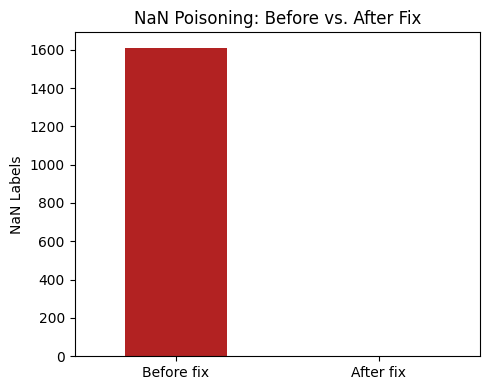

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({"Before fix": 1610, "After fix": 0}).plot(kind="bar", ax=ax, color=["firebrick", "steelblue"])
ax.set_ylabel("NaN Labels")
ax.set_title("NaN Poisoning: Before vs. After Fix")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "nan_fix_impact.png"), dpi=100)
plt.show()

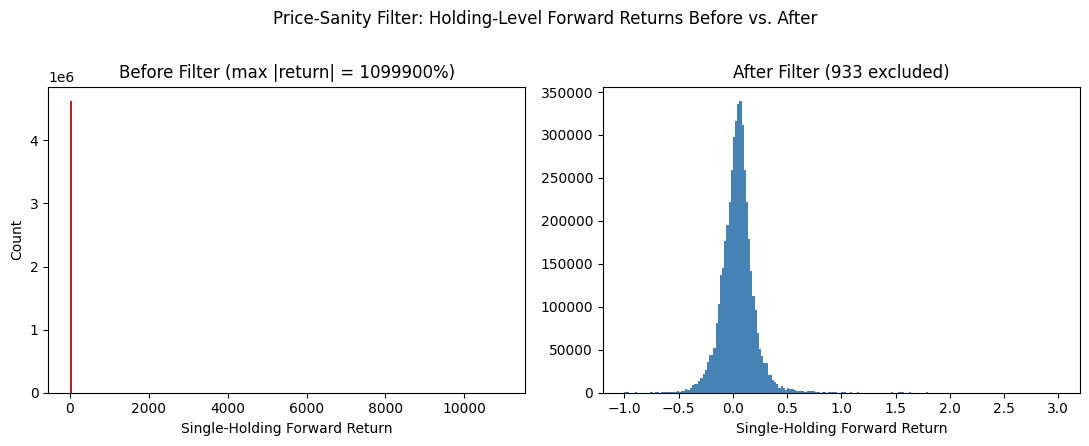

In [15]:
raw_returns = pd.Series(raw_holding_returns)
filtered_returns = raw_returns[raw_returns.abs() <= SANITY_RETURN_LIMIT]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(raw_returns, bins=200, color="firebrick")
axes[0].set_title(f"Before Filter (max |return| = {raw_returns.abs().max():.0%})")
axes[0].set_xlabel("Single-Holding Forward Return")
axes[0].set_ylabel("Count")

axes[1].hist(filtered_returns, bins=200, color="steelblue")
axes[1].set_title(f"After Filter ({len(raw_returns) - len(filtered_returns)} excluded)")
axes[1].set_xlabel("Single-Holding Forward Return")

fig.suptitle("Price-Sanity Filter: Holding-Level Forward Returns Before vs. After")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "sanity_filter_impact.png"), dpi=100)
plt.show()

Before filtering, a small number of holding-level forward returns are extreme outliers driven by bad price entries, the RDS case above (156.5x) is one example, and the most extreme reaches nearly 11,000x, which distort the raw distribution into a single spike near zero. The ±300% sanity filter removes 933 such cases (0.02% of 4,621,933 holding-quarter return calculations), leaving a distribution of genuine returns.

## Select the Loss Threshold

A -15% threshold (the problem statement's initial estimate) was checked empirically and found to flag only 0.6% of portfolios, too rare for meaningful model training. Several thresholds were tested before selecting a final value.

In [16]:
for threshold in [-0.15, -0.12, -0.10, -0.07, -0.05]:
    proportion = (label_df["weighted_excess_return"] < threshold).mean()
    count = (label_df["weighted_excess_return"] < threshold).sum()
    print(f"Threshold {threshold:.0%}: {count} positive cases ({proportion:.1%})")

Threshold -15%: 118 positive cases (0.6%)
Threshold -12%: 192 positive cases (0.9%)
Threshold -10%: 252 positive cases (1.2%)
Threshold -7%: 493 positive cases (2.4%)
Threshold -5%: 846 positive cases (4.2%)


In [17]:
print(label_df["weighted_excess_return"].describe())

count    20244.000000
mean         0.008033
std          0.050241
min         -1.049391
25%         -0.007318
50%          0.006063
75%          0.020447
max          0.846632
Name: weighted_excess_return, dtype: float64


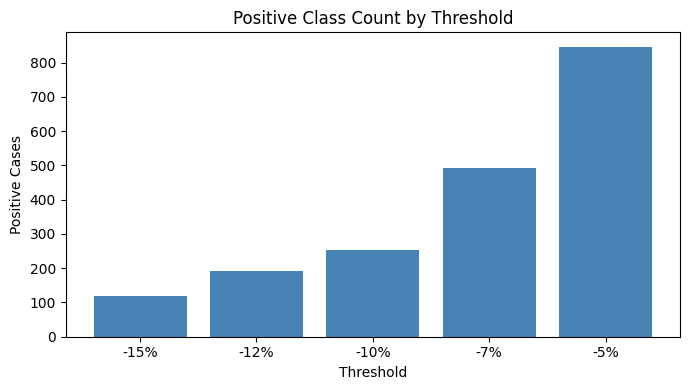

In [18]:
thresholds = [-0.15, -0.12, -0.10, -0.07, -0.05]
counts = [(label_df["weighted_excess_return"] < t).sum() for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"{t:.0%}" for t in thresholds], counts, color="steelblue")
ax.set_xlabel("Threshold")
ax.set_ylabel("Positive Cases")
ax.set_title("Positive Class Count by Threshold")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "threshold_selection.png"), dpi=100)
plt.show()

Positive case counts rise sharply as the threshold moves from -15% toward -5%, illustrating why -15% was too rare to support model training.

In [19]:
loss_threshold = -0.05

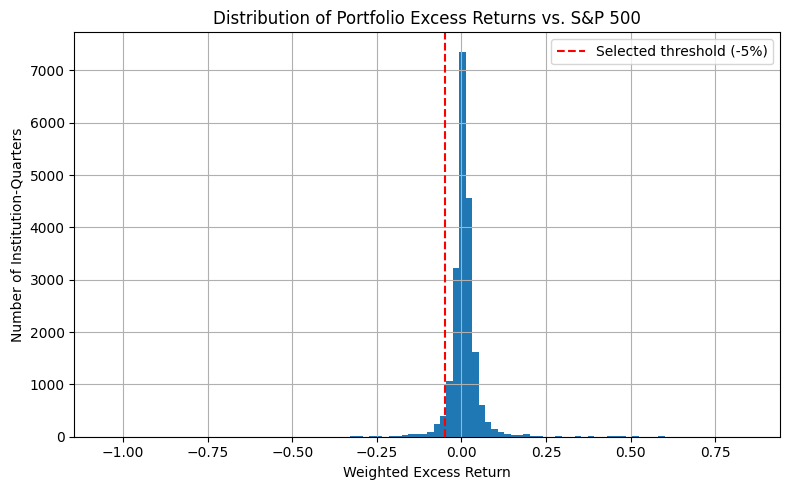

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
label_df["weighted_excess_return"].hist(bins=100, ax=ax)
ax.axvline(loss_threshold, color="red", linestyle="--", label=f"Selected threshold ({loss_threshold:.0%})")
ax.set_xlabel("Weighted Excess Return")
ax.set_ylabel("Number of Institution-Quarters")
ax.set_title("Distribution of Portfolio Excess Returns vs. S&P 500")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "excess_return_distribution.png"), dpi=100)
plt.show()

The distribution is centred near zero, with a long left tail. The selected -5% threshold sits well within this tail, flagging genuinely unusual underperformance rather than ordinary quarterly variation.

## Finalise Label and Save Modelling Table

-5% is selected as the final threshold (4.2% positive class), balancing a meaningful underperformance definition against having enough positive examples to train on.

In [21]:
label_df["label"] = (label_df["weighted_excess_return"] < loss_threshold).astype(int)

model_data = portfolio_features.merge(
    label_df[["cik", "quarter", "weighted_excess_return", "label"]],
    on=["cik", "quarter"], how="inner"
)

model_data.to_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"), index=False)
print(f"Final modelling table: {model_data.shape}")
print(model_data["label"].value_counts())

Final modelling table: (20244, 10)
label
0    19398
1      846
Name: count, dtype: int64


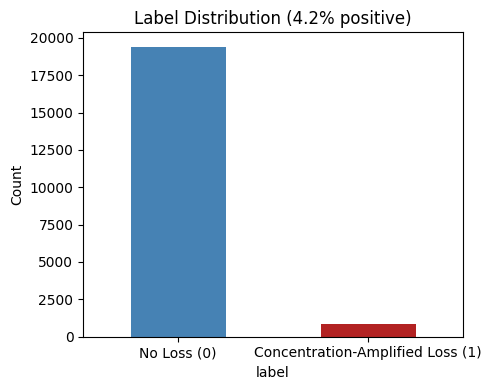

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
model_data["label"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_xticklabels(["No Loss (0)", "Concentration-Amplified Loss (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Label Distribution ({model_data['label'].mean():.1%} positive)")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "label_balance.png"), dpi=100)
plt.show()

The label is heavily imbalanced (4.2% positive), confirming that accuracy alone would be a misleading evaluation metric for the models built on this data.

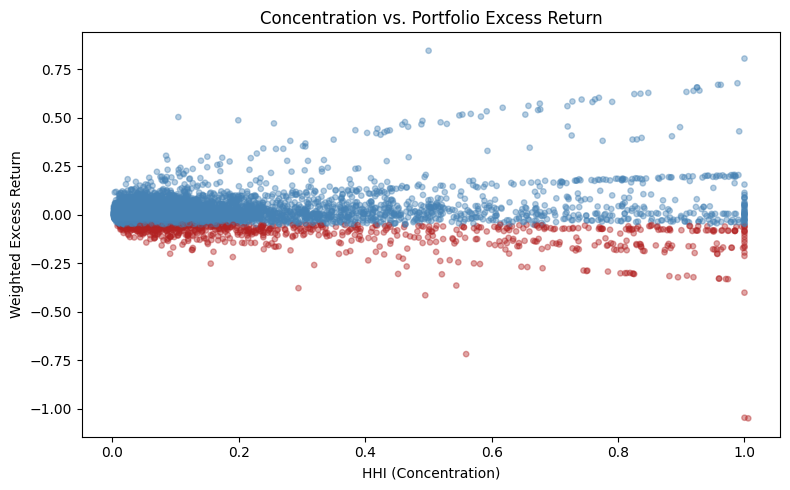

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = model_data["label"].map({0: "steelblue", 1: "firebrick"})
ax.scatter(model_data["hhi"], model_data["weighted_excess_return"], c=colors, alpha=0.4, s=15)
ax.set_xlabel("HHI (Concentration)")
ax.set_ylabel("Weighted Excess Return")
ax.set_title("Concentration vs. Portfolio Excess Return")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "hhi_vs_excess_return.png"), dpi=100)
plt.show()

Red (loss) points are visibly concentrated toward higher HHI values, a first visual indication that concentration is genuinely associated with the risk this study aims to predict.